In [ ]:
import pandas as pd
df = pd.read_csv("../data/processed/rfm_analysis.csv") #Loading the csv file
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96095 entries, 0 to 96094
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  96095 non-null  str    
 1   last_purchase_date  96095 non-null  str    
 2   number_of_orders    96095 non-null  int64  
 3   total_spent         96095 non-null  float64
 4   recency_days        96095 non-null  int64  
 5   r_score             96095 non-null  int64  
 6   f_score             96095 non-null  int64  
 7   m_score             96095 non-null  int64  
 8   rfm_score           96095 non-null  int64  
 9   customer_segment    96095 non-null  str    
dtypes: float64(1), int64(6), str(3)
memory usage: 7.3 MB


In [22]:
df.groupby("customer_segment")["customer_unique_id"].count().sort_values(ascending=False) #Customer Count by segments

customer_segment
Others            38583
Lost Customer     14908
Big Spenders      11690
Loyal Customer    10957
At Risk            8235
New Customer       7902
Champion           3820
Name: customer_unique_id, dtype: int64

In [ ]:
# Insight:
# Most customers fall into "Others" and "Lost Customers" segments.
# This shows that a large portion of users are either inactive or not highly engaged.
# It suggests that customer retention is a major challenge for the business.

In [23]:
df.groupby("customer_segment")["total_spent"].mean().sort_values(ascending=False) #Average amount spent per customer segments

customer_segment
Lost Customer     627.628916
New Customer      622.990600
Others            362.242256
At Risk           144.541144
Loyal Customer    122.279169
Big Spenders       79.537307
Champion           79.028105
Name: total_spent, dtype: float64

In [ ]:
# Insight:
# Surprisingly, "Lost Customers" have the highest average spending.
# This means that some high-value customers have stopped purchasing.
# It highlights a critical business problem — valuable customers are not being retained.

# "New Customers" also show high average spending.
# This indicates that the business is good at getting quality customers.
# However, many of them do not return, pointing towards weak retention strategies.

# "Champions" and "Loyal Customers" have lower average spending.
# This suggests that they purchase frequently but spend smaller amounts per order.
# These customers are important for long-term stability but may need upselling strategies.

# "At Risk" customers have moderate spending but are becoming inactive.
# These customers were previously engaged and may be close to churning.
# Targeted re-engagement campaigns could help bring them back.

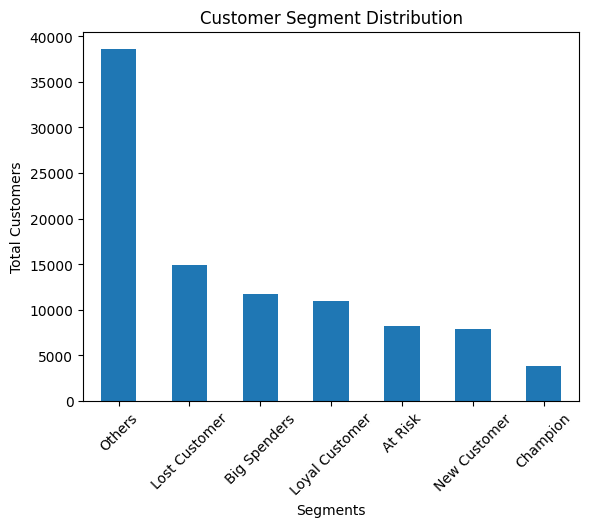

In [24]:
import matplotlib.pyplot as plt
customer_count = df.groupby("customer_segment")["customer_unique_id"].count().sort_values(ascending=False)

plt.figure()
customer_count.plot(kind="bar")
plt.title("Customer Segment Distribution")
plt.xlabel("Segments")
plt.ylabel("Total Customers")
plt.xticks(rotation=45)
plt.show()

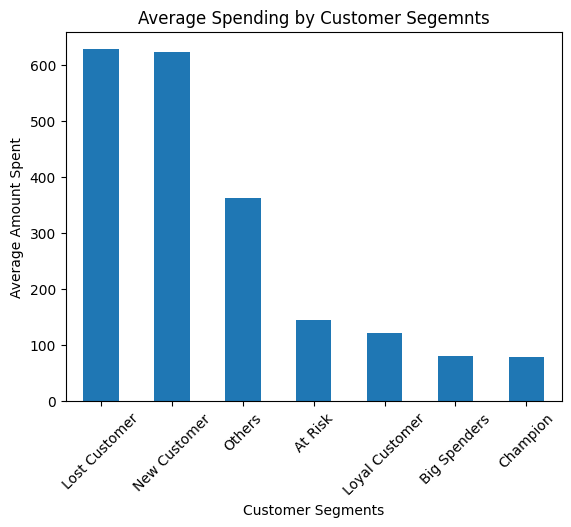

In [25]:
avg_total_spent = df.groupby("customer_segment")["total_spent"].mean().sort_values(ascending=False)

plt.figure()
avg_total_spent.plot(kind="bar")
plt.title("Average Spending by Customer Segemnts")
plt.xlabel("Customer Segments")
plt.ylabel("Average Amount Spent")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#------------Final Insight----------#
# The business shows strong customer acquisition but weak retention.
# High-value customers are being lost over time, which impacts long-term revenue.
# Focusing on retention strategies such as loyalty programs, personalized offers,
# and re-engagement campaigns can significantly improve business performance.